<a href="https://colab.research.google.com/github/trialdyk/marchine-learning/blob/main/JS06/JS06_Lab5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Praktikum 5 - Klasifikasi Citra Siang dan Malam

Pra pengolahan data citra, ekstraksi fitur tingkat kecerahan (average brightness) pada ruang warna HSV, serta klasifikasi menggunakan metode Threshold dan SVM.

## Langkah 0 - Persiapan & Import Library

In [1]:
!curl -s -L -A "Mozilla/5.0" "https://1812311909-files.gitbook.io/~/files/v0/b/gitbook-x-prod.appspot.com/o/spaces%2FYHOv2XH8FJMJSMsnhwNa%2Fuploads%2F9IvI7imHRxFYT9gtRGh7%2Fimages.zip?alt=media&token=d1bc0a22-4056-4a11-a801-04f245ee0e62" -o images.zip
!unzip -q -o images.zip

In [2]:
# Import Required Libraries
from pathlib import Path
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import cv2
import random
import numpy as np
import pandas as pd

In [3]:
# Image directories
train_dir = "images/training/"
test_dir = "images/test/"

## Langkah 1 - Load Data dan Visualisasikan

In [4]:
def load_dataset(img_dir):
    p = Path(img_dir)
    dirs = p.glob('*')
    img_list = []
    for dir in dirs:
        label = str(dir).split('/')[-1]
        for file in dir.glob('*.jpg'):
            img = mpimg.imread(file)
            if not img is None:
                img_list.append((img, label))
    return img_list

In [5]:
# Load training data
train_img = load_dataset(train_dir)

In [6]:
# Check the first data
train_img[0]

(array([[[100, 129, 147],
         [101, 130, 148],
         [101, 130, 148],
         ...,
         [ 89, 106, 122],
         [ 86,  99, 116],
         [121, 134, 151]],
 
        [[100, 129, 147],
         [101, 130, 148],
         [101, 130, 148],
         ...,
         [ 89, 106, 122],
         [ 86,  99, 116],
         [121, 134, 151]],
 
        [[100, 129, 147],
         [101, 130, 148],
         [101, 130, 148],
         ...,
         [ 89, 106, 122],
         [ 86,  99, 116],
         [121, 134, 151]],
 
        ...,
 
        [[152, 136, 102],
         [151, 135, 101],
         [151, 135, 101],
         ...,
         [ 59,  63,  40],
         [ 57,  62,  39],
         [ 54,  59,  36]],
 
        [[153, 137, 103],
         [152, 136, 102],
         [151, 135, 101],
         ...,
         [ 59,  63,  40],
         [ 56,  61,  38],
         [ 51,  56,  33]],
 
        [[179, 163, 129],
         [178, 162, 128],
         [177, 161, 127],
         ...,
         [ 64,  68,  45],
  

In [7]:
# Random size checking
pick_random = np.random.randint(0, len(train_img))
print(f'Image {pick_random}')
print(train_img[pick_random][0].shape)

Image 119
(737, 1024, 3)


In [8]:
# Function to Visualize
def random_img_viz(img_list):
    rand_num = np.random.randint(0, len(img_list))
    img = img_list[rand_num][0]
    label = img_list[rand_num][1]
    label_str = 'day' if label == 'day' else 'night'
    plt.imshow(img)
    print(f'Shape\t: {img.shape}')
    print(f'Label\t: {label}')

Shape	: (458, 800, 3)
Label	: night


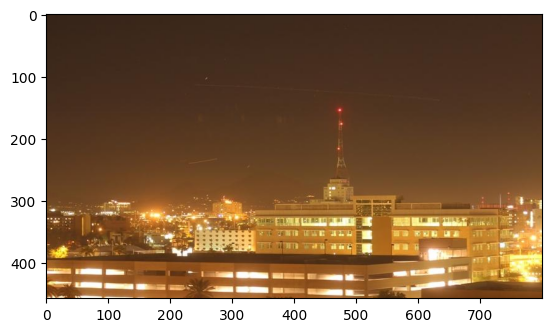

In [9]:
random_img_viz(train_img)

## Langkah 3 - Pra Pengolahan Data

In [10]:
def standarized_input(image):
    # resize to w: 1100, h:600
    std_img = cv2.resize(image, (1100,600))
    return std_img

In [11]:
def label_encoder(label):
    # Encode the label
    # day as 1; night as 0
    num_val = 0
    if(label == 'day'):
        num_val = 1
    return num_val

In [12]:
def preprocess(img_list):
    std_img_list = []
    for item in img_list:
        image = item[0]
        label = item[1]
        # Standarized the image
        std_img = standarized_input(image)
        # Create the label
        img_label = label_encoder(label)
        std_img_list.append((std_img, img_label))
    return std_img_list

In [13]:
train_std_img_list = preprocess(train_img)

In [14]:
# Random size checking
pick_random = np.random.randint(0, len(train_std_img_list))
print(f'Image {pick_random}')
print(train_std_img_list[pick_random][0].shape)

Image 147
(600, 1100, 3)


## Langkah 4 - Ekstraksi Fitur (Average Brightness HSV)

In [15]:
# Get feature based on average brightness using HSV colorspace
def avg_brightness(image):
    # Convert image to HSV
    img_hsv = cv2.cvtColor(image, cv2.COLOR_RGB2HSV)
    # Calculate the avg of brightness
    sum_brightness = np.sum(img_hsv[:,:,2]) # take the 3rd value which is the V channel
    area = image.shape[0] * image.shape[1]
    avg = sum_brightness / area
    return avg

Image 227
Avg Brightness: 92.7016


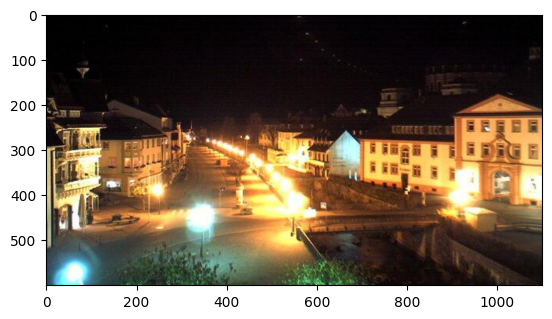

In [16]:
# Check on random image
rand_img = np.random.randint(0, len(train_std_img_list))
feature_img = train_std_img_list[rand_img][0]
avg_img = avg_brightness(feature_img)
print(f'Image {rand_img}')
print(f'Avg Brightness: {avg_img:.4f}')
plt.imshow(feature_img)

## Langkah 5 - Klasifikasi dengan Metode Threshold

In [17]:
def predict_label(img, threshold):
    # Compute average brightness
    avg = avg_brightness(img)
    pred = 0
    # Predict the label based on user defined threshold
    if avg > threshold:
        pred = 1
    return pred

Image 26
Actual label: 1
Predicted label: 1


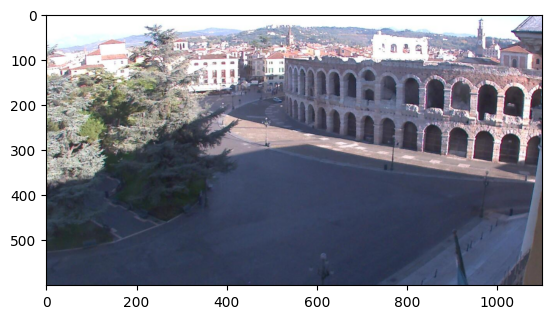

In [18]:
# Test the classifier on train data
rand_img = np.random.randint(0, len(train_std_img_list))
pred = predict_label(train_std_img_list[rand_img][0], threshold=120)

# Evaluate
print(f'Image {rand_img}')
print(f'Actual label: {train_std_img_list[rand_img][1]}')
print(f'Predicted label: {pred}')
plt.imshow(train_std_img_list[rand_img][0])

## Langkah 6 - Evaluasi Manual Threshold

In [19]:
def evaluate(img_list, threshold):
    miss_labels = []
    for file in img_list:
        img = file[0]
        label = file[1]
        pred_label = predict_label(img, threshold)
        if pred_label != label:
            miss_labels.append((img, pred_label, label))
    total_img = len(img_list)
    corr_pred = total_img - len(miss_labels)
    accuracy = corr_pred / total_img
    print(f'Accuracy: {accuracy:.4f}')

In [20]:
# Evaluate on train data
evaluate(train_std_img_list, threshold=120)

Accuracy: 0.8417


In [21]:
# Evaluate on test data
test_img = load_dataset(test_dir)
test_std_img_list = preprocess(test_img)
evaluate(test_std_img_list, threshold=120)

Accuracy: 0.8688


## Klasifikasi dengan SVM (Langkah Alternatif)

### Langkah 4 Alternatif - Membuat Feature Vectors

In [22]:
# Stored in Pandas dataframe
def extract_avg_bright_feature(img_list):
    avg_list = []
    labels = []
    for img in img_list:
        img_avg = avg_brightness(img[0])
        img_label = img[1]
        avg_list.append(img_avg)
        labels.append(img_label)
    data = np.column_stack((avg_list, labels))
    df = pd.DataFrame(data, columns=['AVG_BRIGHT', 'LABELS'])
    return df

In [23]:
# Extract feature on train data
train_avg_img = extract_avg_bright_feature(train_std_img_list)
print(f'Shape: {train_avg_img.shape}')
train_avg_img.head()

Shape: (240, 2)


,AVG_BRIGHT,LABELS
0,105.600792,1.0
1,117.414992,1.0
2,144.075127,1.0
3,143.364305,1.0
4,170.984826,1.0


In [24]:
# Do the same thing on test data
test_avg_img = extract_avg_bright_feature(test_std_img_list)
print(f'Shape: {test_avg_img.shape}')
test_avg_img.head()

Shape: (160, 2)


,AVG_BRIGHT,LABELS
0,116.048989,1.0
1,194.228062,1.0
2,125.659120,1.0
3,189.320711,1.0
4,110.689276,1.0


### Langkah 5 Alternatif - Buat Model SVM

In [25]:
from sklearn.svm import SVC

X_train = train_avg_img.iloc[:,0].values.reshape(-1,1)
y_train = train_avg_img.iloc[:,1]
X_test = test_avg_img.iloc[:,0].values.reshape(-1,1)
y_test = test_avg_img.iloc[:,1]

model = SVC()
model.fit(X_train, y_train)

SVC()

### Langkah 6 Alternatif - Evaluasi Model SVM

In [26]:
from sklearn.metrics import accuracy_score

y_train_pred = model.predict(X_train)
acc_train = accuracy_score(y_train, y_train_pred)

y_test_pred = model.predict(X_test)
acc_test = accuracy_score(y_test, y_test_pred)

print(f'Accuracy on train: {acc_train}')
print(f'Accuracy on test: {acc_test}')

Accuracy on train: 0.8583333333333333
Accuracy on test: 0.9
